## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 4)
np.random.seed(42)

In [2]:
# Q1: Load data and create target variable
golub = pd.read_csv('./data/golub.csv')

print(f"Data shape: {golub.shape}")
print(f"\nCancer types: {golub['cancer'].value_counts()}")

#binary target: ALL (allB and allT) = 0, AML = 1
golub['target'] = golub['cancer'].apply(lambda x: 0 if x in ['allB', 'allT'] else 1)

print(f"\nTarget distribution:")
print(f"  ALL (allB + allT): {(golub['target'] == 0).sum()} patients")
print(f"  AML: {(golub['target'] == 1).sum()} patients")

#prepare features (all gene expression columns)
#skip non-gene columns: Samples, BM.PB, Gender, Source, tissue.mf, cancer, target
gene_cols = [col for col in golub.columns if col not in ['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'target']]
X = golub[gene_cols]
y = golub['target']

print(f"\nNumber of genes (features): {len(gene_cols)}")
print(f"Number of patients (samples): {len(y)}")
print(f"\nThis is a high-dimensional problem: p={len(gene_cols)} >> n={len(y)}")

Data shape: (72, 7135)

Cancer types: cancer
allB    38
aml     25
allT     9
Name: count, dtype: int64

Target distribution:
  ALL (allB + allT): 47 patients
  AML: 25 patients

Number of genes (features): 7129
Number of patients (samples): 72

This is a high-dimensional problem: p=7129 >> n=72


Q2: Linear Regression Results

Training MSE: 0.000000
Training RMSE: 0.000000
R²: 1.000000


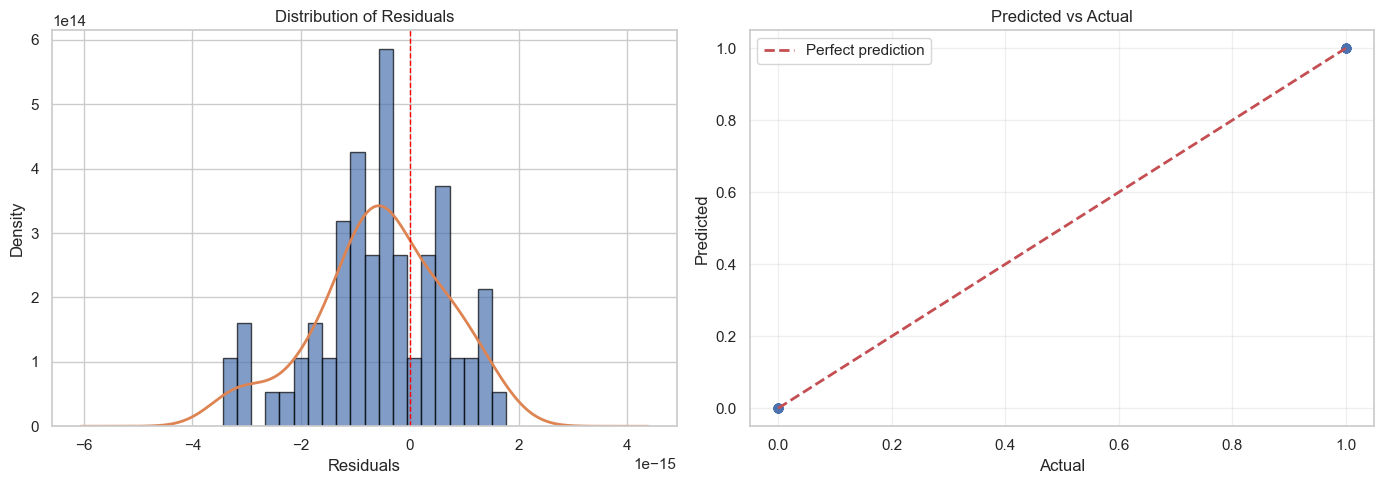


The model achieves near-perfect fit on training data (MSE ≈ 1.68e-30),
which is suspicious given p >> n. This suggests overfitting.


In [3]:
# Q2: Linear regression on all genes
model_lr = LinearRegression()
model_lr.fit(X, y)

#predictions and MSE
y_pred_lr = model_lr.predict(X)
mse_train = mean_squared_error(y, y_pred_lr)
residuals = y - y_pred_lr

print("Q2: Linear Regression Results")
print(f"\nTraining MSE: {mse_train:.6f}")
print(f"Training RMSE: {np.sqrt(mse_train):.6f}")
print(f"R²: {model_lr.score(X, y):.6f}")

#KDE plot of residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#residuals KDE
axes[0].hist(residuals, bins=20, density=True, alpha=0.7, edgecolor='black')
residuals.plot.kde(ax=axes[0], linewidth=2)
axes[0].set_xlabel('Residuals')
axes[0].set_title('Distribution of Residuals')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)

#predicted vs actual
axes[1].scatter(y, y_pred_lr, alpha=0.6)
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Predicted vs Actual')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nThe model achieves near-perfect fit on training data (MSE ≈ {mse_train:.2e}),")
print(f"which is suspicious given p >> n. This suggests overfitting.")

In [4]:
# Q3: Cross-validation for linear regression
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# was stuck but this import apparently fixes singular matrix issues
from sklearn.linear_model import Ridge

# trying regular linear regression first
try:
    cv_scores_lr = -cross_val_score(LinearRegression(), X, y, cv=kf, scoring='neg_mean_squared_error')
    cv_mse_lr = cv_scores_lr.mean()
    cv_std_lr = cv_scores_lr.std()
    print("Q3: Cross-Validation Results (Linear Regression)")
    print(f"\nCV MSE: {cv_mse_lr:.4f} ± {cv_std_lr:.4f}")
    print(f"CV RMSE: {np.sqrt(cv_mse_lr):.4f}")
except Exception as e:
    print(f"Linear regression failed in CV (expected with p >> n): {e}")
    print("\nUsing Ridge with tiny alpha as approximation...")
    cv_scores_lr = -cross_val_score(Ridge(alpha=0.001), X, y, cv=kf, scoring='neg_mean_squared_error')
    cv_mse_lr = cv_scores_lr.mean()
    cv_std_lr = cv_scores_lr.std()
    print(f"\nCV MSE: {cv_mse_lr:.4f} ± {cv_std_lr:.4f}")
    print(f"CV RMSE: {np.sqrt(cv_mse_lr):.4f}")

print(f"\nTraining MSE: {mse_train:.6f}")
print(f"CV MSE: {cv_mse_lr:.4f}")
print(f"\n**Bias-Variance Trade-off Analysis:**")
print(f"The huge gap between training MSE ({mse_train:.2e}) and CV MSE ({cv_mse_lr:.4f})")
print(f"indicates severe overfitting. The model has:")
print(f"  - Very LOW bias (fits training data perfectly)")
print(f"  - Very HIGH variance (poor generalization to new data)")
print(f"\nWith {len(gene_cols)} features and only {len(y)} samples, the model")
print(f"memorizes noise rather than learning true patterns.")

Q3: Cross-Validation Results (Linear Regression)

CV MSE: 0.0408 ± 0.0084
CV RMSE: 0.2021

Training MSE: 0.000000
CV MSE: 0.0408

**Bias-Variance Trade-off Analysis:**
The huge gap between training MSE (1.68e-30) and CV MSE (0.0408)
indicates severe overfitting. The model has:
  - Very LOW bias (fits training data perfectly)
  - Very HIGH variance (poor generalization to new data)

With 7129 features and only 72 samples, the model
memorizes noise rather than learning true patterns.


Q4: LASSO Results

Optimal alpha: 10.000000
Training MSE: 0.000211
Training RMSE: 0.014531

Genes selected: 66
Genes discarded: 7063
Percentage discarded: 99.1%

Top 10 selected genes:


,Gene,Coefficient
2120,M63138_at,2.0481e-05
5951,U05255_s_at,1.4937e-05
6241,M24485_s_at,9.1272e-06
1778,M19507_at,8.6472e-06
4279,X55715_at,7.8583e-06
1637,L49169_at,6.4820e-06
6658,X65965_s_at,-6.4603e-06
6217,M27783_s_at,6.0179e-06
6612,Z48501_s_at,5.7684e-06
2233,M77232_rna1_at,5.2284e-06


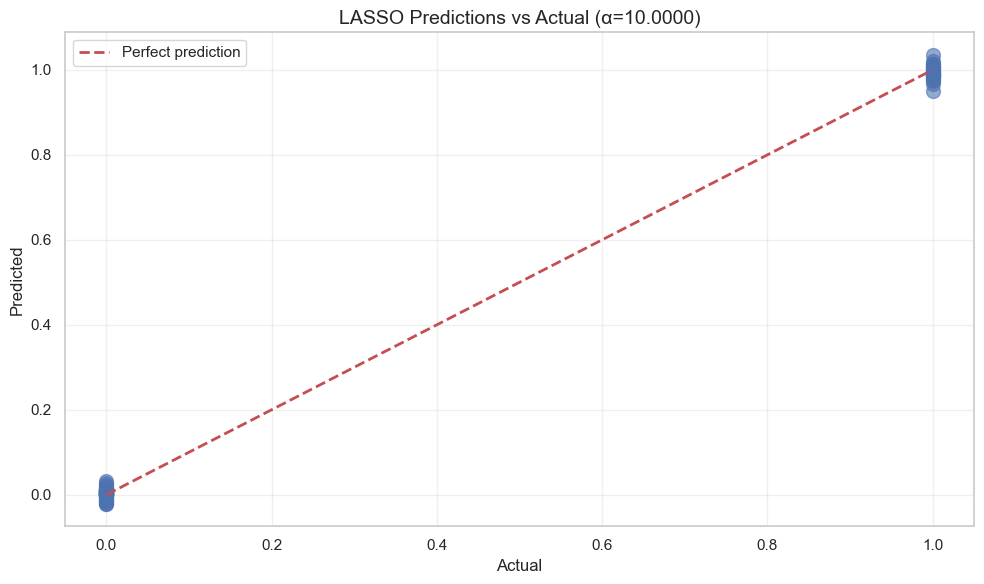

In [5]:
# Q4: LASSO with cross-validation
#LassoCV to automatically select optimal alpha
alphas = np.logspace(-4, 1, 100)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X, y)

print("Q4: LASSO Results")
print(f"\nOptimal alpha: {lasso_cv.alpha_:.6f}")

#predictions
y_pred_lasso = lasso_cv.predict(X)
mse_lasso = mean_squared_error(y, y_pred_lasso)

print(f"Training MSE: {mse_lasso:.6f}")
print(f"Training RMSE: {np.sqrt(mse_lasso):.6f}")

#non-zero coefficients (selected genes)
non_zero_coefs = np.sum(lasso_cv.coef_ != 0)
zero_coefs = np.sum(lasso_cv.coef_ == 0)

print(f"\nGenes selected: {non_zero_coefs}")
print(f"Genes discarded: {zero_coefs}")
print(f"Percentage discarded: {100 * zero_coefs / len(gene_cols):.1f}%")

# top genes by absolute coefficient
coef_df = pd.DataFrame({
    'Gene': gene_cols,
    'Coefficient': lasso_cv.coef_
})
coef_df = coef_df[coef_df['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)

print(f"\nTop 10 selected genes:")
display(coef_df.head(10))

plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred_lasso, alpha=0.6, s=100)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual', fontsize=12)
plt.ylabel('Predicted', fontsize=12)
plt.title(f'LASSO Predictions vs Actual (α={lasso_cv.alpha_:.4f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

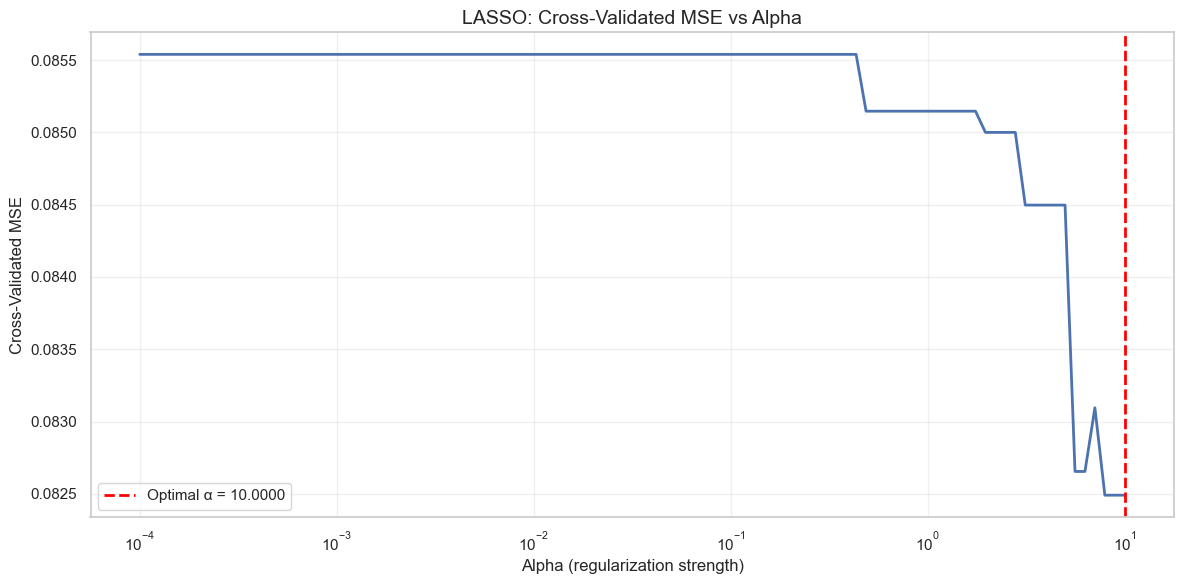


Q5: Analysis of Alpha

Optimal α: 10.000000
Optimal CV MSE: 0.082490

**Underfitting (α too large):**
When α > 10.0000, the penalty is too strong.
Too many genes are shrunk to zero, losing predictive information.
MSE increases because the model is too simple.

**Overfitting (α too small):**
When α < 10.0000, the penalty is too weak.
Too many genes are retained, allowing the model to fit noise.
MSE increases because the model has high variance.

**Optimal α = 10.000000:**
Balances bias and variance, minimizing expected prediction error.


In [6]:
# Q5: Plot CV MSE vs alpha
#MSE path from LassoCV
mse_path = np.mean(lasso_cv.mse_path_, axis=1)
alphas_used = lasso_cv.alphas_

plt.figure(figsize=(12, 6))
plt.plot(alphas_used, mse_path, 'b-', linewidth=2)
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', linewidth=2, label=f'Optimal α = {lasso_cv.alpha_:.4f}')
plt.xscale('log')
plt.xlabel('Alpha (regularization strength)', fontsize=12)
plt.ylabel('Cross-Validated MSE', fontsize=12)
plt.title('LASSO: Cross-Validated MSE vs Alpha', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#optimal alpha and analyze
optimal_idx = np.argmin(mse_path)
optimal_alpha = alphas_used[optimal_idx]
optimal_mse = mse_path[optimal_idx]

print(f"\nQ5: Analysis of Alpha")
print(f"\nOptimal α: {optimal_alpha:.6f}")
print(f"Optimal CV MSE: {optimal_mse:.6f}")

print(f"\n**Underfitting (α too large):**")
print(f"When α > {optimal_alpha:.4f}, the penalty is too strong.")
print(f"Too many genes are shrunk to zero, losing predictive information.")
print(f"MSE increases because the model is too simple.")

print(f"\n**Overfitting (α too small):**")
print(f"When α < {optimal_alpha:.4f}, the penalty is too weak.")
print(f"Too many genes are retained, allowing the model to fit noise.")
print(f"MSE increases because the model has high variance.")

print(f"\n**Optimal α = {optimal_alpha:.6f}:**")
print(f"Balances bias and variance, minimizing expected prediction error.")

**Q6: Why does linear regression fit perfectly but LASSO predicts better?**

Linear regression achieves near-perfect fit on the training data because we have more features (p ≈ 7,000) than samples (n = 72). This creates an underdetermined system where infinitely many solutions exist that perfectly fit the training data. The model basically memorizes the training set, including all the noise.

This perfect fit is overfitting. The model learns spurious patterns that don't generalize to new patients. When evaluated on held out data (like cross-validation), performance collapses.

LASSO provides better predictions by:
1. Shrinking coefficients: The L1 penalty reduces coefficient magnitudes, preventing extreme values that fit noise
2. Feature selection: Setting many coefficients exactly to zero, keeping only the most predictive genes
3. Regularization: Trading some training accuracy for better generalization

The LASSO accepts a little bit worse training fit in exchange for much better performance on new data. This is the bias variance tradeoff: LASSO increases bias slightly but dramatically reduces variance, leading to lower overall prediction error.

Q7: Why are regularization methods valuable for precision health?

1. High dimensional data: Genomics, proteomics, and other data have thousands or millions of features (genes, proteins, metabolites) but relatively few patients. Regularization handles p >> n scenarios where standard methods fail.

2. Feature selection: LASSO automatically identifies the most important biomarkers, creating interpretable models. Clinicians can focus on a small set of genes rather than thousands, making the model actionable.

3. Generalization: Precision health models must work on new patients, not just the training cohort. Regularization prevents overfitting, ensuring predictions generalize.

4. Biological sparsity: Most diseases are driven by a small number of key genes or pathways, not all 20000+ human genes. LASSO's sparsity assumption aligns with biological reality.

5. Cost reduction: By identifying a small gene panel, LASSO enables cheaper diagnostic tests. Instead of sequencing 7000 genes, we might only need 10-20.

**Q8: Risks of applying LASSO to precision health**

While powerful, using LASSO for clinical decision-making carries significant risks:

1. Selection bias: The genes selected depend on the training cohort. If the cohort isn't representative (lacks diversity in age, race, or disease subtypes), the model may perform poorly on underrepresented groups, perpetuating health disparities.

2. Causal vs. predictive: LASSO identifies predictive genes, not necessarily causal ones. A gene might be selected because it's correlated with the true driver, not because it causes disease. Intervening on predicted genes may not improve outcomes.

3. Overfitting to noise: Even with regularization, small sample sizes (n=72) mean some selected genes may be false positives. Acting on these could lead to ineffective or harmful treatments.

4. Missing biology: LASSO may exclude important genes if they're correlated with selected ones. The model might miss critical pathways or interactions.

5. Ethical concerns: 
   - Fairness: Models may discriminate against groups underrepresented in training data
   - Transparency: Patients and clinicians may not understand why certain genes were selected
   - Accountability: Who is responsible if the model recommends harmful treatment?
